# Potabilité de l'eau

---

## Corrélations linéaires - Pearson

À partir de ce jeu de données, une problématique centrale est apparue : existe-t-il des corrélations entre les différents indicateurs chimiques qui définissent la potabilité de l'eau ?

Pour suivre une démarche scientifique rigoureuse, j'ai débuté mon analyse par la méthode la plus directe : les corrélations de Pearson. Cette étape permet de vérifier l'existence de relations linéaires simples entre les variables.

![Correlations lineaires](./img/Rplot.png)

Les résultats obtenus (visibles ci-dessus) indiquent clairement qu'aucune relation linéaire significative n'existe. Les coefficients sont proches de zéro, ce qui démontre, par exemple, que l'augmentation du taux de Sulfate ne fait pas augmenter la potabilité de manière proportionnelle ou constante.

Ce constat est crucial : il prouve qu'une analyse statistique classique est ici insuffisante. La potabilité ne dépend pas de facteurs isolés évoluant de façon prévisible, mais de relations plus complexes. Il n'est donc pas utile de poursuivre dans la voie de la régression linéaire ; c'est ce qui justifie l'utilisation d'un modèle de Machine Learning non-linéaire (Random Forest dans notre cas) pour capturer les signaux cachés et les effets de seuil.

---

## Machine Learning - Random Forest

Pour que le modèle de Machine Learning puisse apprendre efficacement, une étape de nettoyage est indispensable. J'ai choisi de traiter les valeurs manquantes par imputation par la médiane, afin de ne pas perdre d'informations précieuses, notamment sur le Sulfate (23% de données manquantes) et le pH (15%).

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import script as sc
import seaborn as sns

df = pd.read_csv('data/water_potability.csv')

#print(df.isnull().sum() / len(df) * 100)


#ph                 14.987790
#Hardness            0.000000
#Solids              0.000000
#Chloramines         0.000000
#Sulfate            23.840049
#Conductivity        0.000000
#Organic_carbon      0.000000
#Trihalomethanes     4.945055
#Turbidity           0.000000
#Potability          0.000000

## Preprocessing

X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ph_median = X_train['ph'].median()
sulfate_median = X_train['Sulfate'].median()
trih_median = X_train['Trihalomethanes'].median()

X_train['ph'] = X_train['ph'].fillna(ph_median)
X_train['Sulfate'] = X_train['Sulfate'].fillna(sulfate_median)
X_train['Trihalomethanes'] = X_train['Trihalomethanes'].fillna(trih_median)

X_test['ph'] = X_test['ph'].fillna(ph_median)
X_test['Sulfate'] = X_test['Sulfate'].fillna(sulfate_median)
X_test['Trihalomethanes'] = X_test['Trihalomethanes'].fillna(trih_median)

## Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Après avoir testé plusieurs algorithmes (Régression Logistique, SVM, Random Forest), le Random Forest s'est avéré le plus performant. Son avantage réside dans sa structure en arbres de décision qui lui permet de capturer des règles complexes ("Si le pH est entre X et Y ET que le Sulfate est inférieur à Z...").

In [24]:
## Training

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

## Spot check   

#models = [
#    ('Logistic Regression', LogisticRegression()),
#    ('Random Forest', RandomForestClassifier(random_state=42)),
#    ('SVM', SVC(random_state=42))
#]

#for name, model in models:
    # Training
#    model.fit(X_train_scaled, y_train)
    
    # Prediction
#    y_pred = model.predict(X_test_scaled)
    
    # Evaluation
#    print(f"{name} :")
#    print(classification_report(y_test, y_pred))
#    print(confusion_matrix(y_test, y_pred))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Le modèle affiche une précision de 67 %. En examinant la matrice de confusion, on remarque que le modèle est particulièrement performant pour identifier l'eau non-potable (358 vrais négatifs).

In [25]:
## Prediction

y_pred = model.predict(X_test_scaled)

## Evaluation

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.87      0.77       412
           1       0.61      0.34      0.44       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.60       656
weighted avg       0.66      0.67      0.65       656

[[358  54]
 [160  84]]


Ce résultat est très encourageant car, là où la corrélation de Pearson (linéaire) nous suggérait qu'il n'y avait rien à apprendre des données, le Machine Learning prouve qu'il existe un signal exploitable.

---

## Features importance

Pour valider ma démarche, j'ai extrait l'importance des variables. Le résultat est le point d'orgue de l'étude :

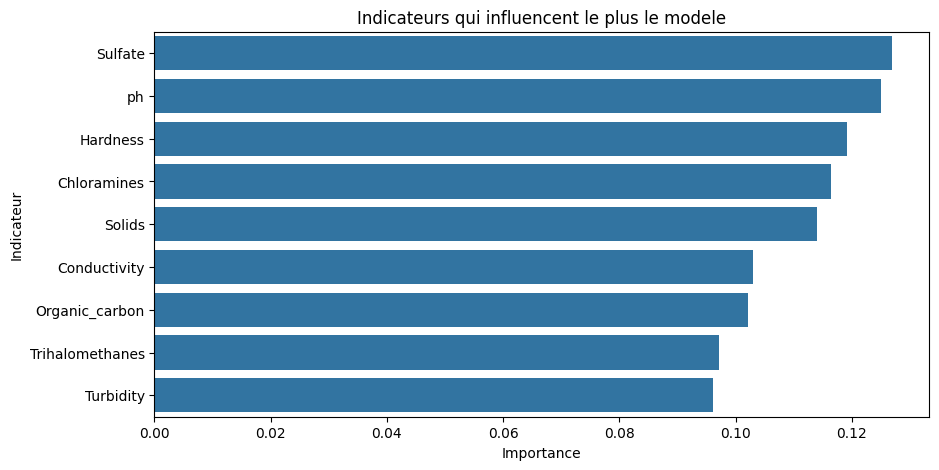

In [26]:
importances = model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Indicateur': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Indicateur', data=fi_df)
plt.title("Indicateurs qui influencent le plus le modele")
plt.show()

C'est ici que je réponds à ma question initiale. Le Sulfate et le pH, qui n'avaient aucune corrélation linéaire avec la potabilité, sont en réalité les deux facteurs les plus déterminants. Cela confirme que la relation entre les indicateurs est réelle mais complexe (non-linéaire).


---
## Analyse des corrélations non-linéaires - PDP 1D
Pour comprendre comment le modèle parvient à prédire la potabilité alors que Pearson ne voyait rien, j'utilise les Partial Dependence Plots. Ces graphiques isolent l'effet d'un indicateur sur la prédiction tout en gardant les autres constants.

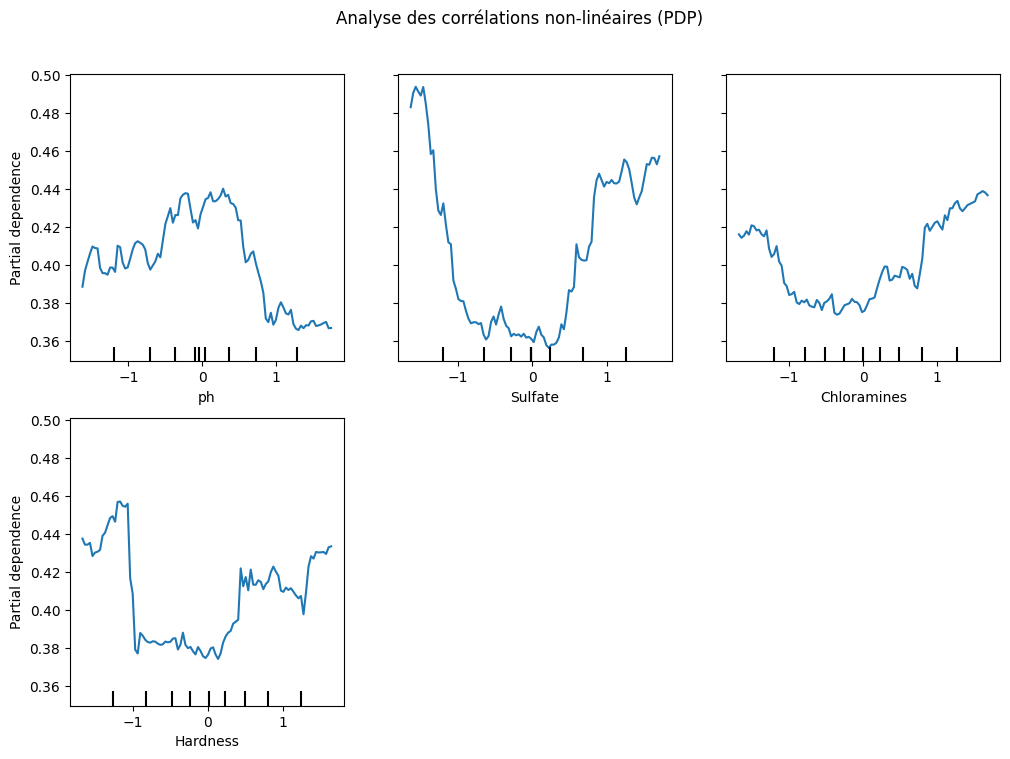

In [27]:
feature_names = X.columns.tolist()
features_to_plot = ['ph', 'Sulfate', 'Chloramines', 'Hardness']
fig, ax = plt.subplots(figsize=(12, 8))
display = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train_scaled,    
    features=features_to_plot,
    feature_names=feature_names,
    kind="average",  
    ax=ax
)

plt.suptitle("Analyse des corrélations non-linéaires (PDP)")
plt.subplots_adjust(top=0.9) 
plt.show()

Interprétation des courbes :
* **Le Sulfate** (L'effet de seuil) : La courbe est le parfait exemple de non-linéarité. La probabilité de potabilité chute brutalement dès que le taux dépasse une certaine valeur (autour de 300 mg/L). Pearson échouait car avant ce seuil, le Sulfate n'a presque pas d'impact.

* **Le pH** (La zone optimale) : On observe que la potabilité est maximale pour un pH neutre. Si l'eau devient trop acide ou trop basique, la courbe descend. Une ligne droite (Pearson) ne peut pas décrire une "bosse" ou une "cloche".

---

## Interaction entre indicateurs - PDP 2D

Enfin, j'ai voulu vérifier si les indicateurs interagissaient entre eux. C'est la forme la plus complexe de corrélation : le fait que l'impact du pH dépende, par exemple, du taux de Sulfate présent.

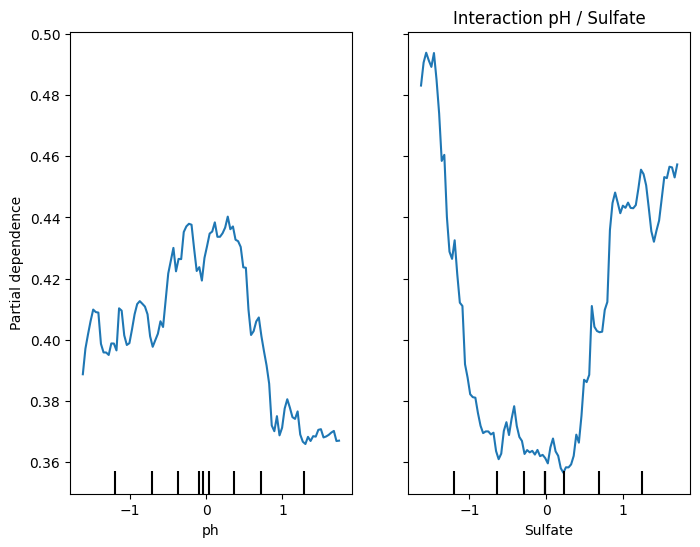

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train_scaled,
    features=['ph', 'Sulfate'],
    feature_names=feature_names,
    ax=ax
)
plt.title("Interaction pH / Sulfate")
plt.show()

Cette Heatmap d'interaction est la preuve ultime de la complexité de nos données. On observe que la potabilité n'est pas définie par des seuils isolés, mais par une combinaison de facteurs.

Par exemple, un pH qui semble "sûr" peut devenir un facteur de non-potabilité si le taux de Sulfate franchit un certain palier. C'est précisément cette interdépendance que la matrice de Pearson était incapable de détecter, et c'est ce qui explique pourquoi notre modèle de Machine Learning est bien plus performant qu'une simple analyse statistique.

---

## Conclusion

Ce projet a permis de démontrer que la potabilité de l'eau est un phénomène complexe qui échappe aux analyses statistiques conventionnelles. Alors que la matrice de Pearson ne révélait aucune corrélation linéaire entre les indicateurs, le modèle Random Forest a réussi à identifier des structures décisionnelles permettant de prédire la potabilité avec une précision de 67 % sur des données réelles.

Grâce aux outils d'interprétabilité (Feature Importance et PDP), nous avons pu percer la "boîte noire" du modèle :
* **Le rôle du Sulfate et du pH** : Ils sont les piliers de la prédiction, non pas par une relation proportionnelle, mais par des effets de seuil critiques (notamment autour de 300 mg/L pour le Sulfate).
* **L'interdépendance** : La heatmap d'interaction a prouvé que la potabilité ne dépend pas d'un facteur isolé, mais d'une synergie entre les éléments chimiques.

Pour aller plus loin et dépasser les 67 % de précision, deux pistes sont envisageables :
* **Qualité des données** : Le taux important de données manquantes sur le Sulfate (23 %) a été compensé par la médiane. Une collecte de données plus complète permettrait d'affiner les seuils de décision.
* **Modèles avancés** : L'utilisation de modèles de gradient boosting (comme XGBoost) ou l'ajout de nouvelles variables environnementales pourrait capturer encore plus finement ces interactions non-linéaires.

En résumé, cette étude prouve que là où les statistiques classiques concluent à une absence de lien, le Machine Learning révèle une logique chimique invisible à l'œil nu, transformant des données brutes en un outil d'aide à la décision pour la santé publique.